# Instance rules and global explanations

Explains the predictions of the formula-bank lasso model with STL rules.

1. Train the model
2. Instance rules for every train and test series
3. Examples of instance rules
4. Global explanations
5. Do global explanations separate their class from the others?

**Metrics** of a rule (or a global explanation) for class $k$, always w.r.t. the classes **predicted by the model**, since a rule explains the model (the true labels only enter the model's accuracy):

- **support** = number of series that satisfy the rule
- **TP** = number of those that the model predicts as $k$
- **precision** = TP / support
- **coverage** = TP / number of series that the model predicts as $k$

**Method** (`stlrocket/instance_rules.py`, hyperparameters in `RULES`):

- **Instance rule** of a series: an AND of up to `n_max` reparametrized formulae that push the model towards its prediction, all satisfied by the series. A beam search picks, among the rules with train support ≥ `n_min`, the one with the largest **lower confidence bound of the train precision** (Wilson, level `confidence`). The bound is close to the precision when many series satisfy the rule and far below it when few do (5/5 → 0.75, 28/30 → 0.85 at 0.9), so it prefers rules that are both precise and well supported.
- **Global explanation** of class $k$: an OR of instance rules of the train series predicted as $k$, added greedily, each time the one covering the most train series of $k$ not covered yet. A rule enters only if those new series are at least `min_new_share` of the class: every extra rule can bring false positives on new series, while the series the rules cover mostly overlap.
- **Simplification** of every rule, instance rules and the rules of the OR alike: an `and`/`or` replaced by one of its children, double `not` removed, thresholds rounded to `decimals` decimals, only where the train series satisfying the rule stay exactly the same. This removes branches that are dead for that rule: a branch can matter for one cut and not for another, so the same formula simplifies differently in different rules. Rules are shown and evaluated as their simplified formula: identical metrics on train, possibly slightly different on test.

In [13]:
import sys
sys.path.insert(0, "..")  # repo root, for the local stlrocket package

from functools import reduce
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torcheck.stl import Or

from stlrocket.config import ExperimentConfig
from stlrocket.data import load_dataset
from stlrocket.features import build_formula_bank, eval_robustness
from stlrocket.classifier import train_classifier
from stlrocket.formula_sampler import F0
from stlrocket import instance_rules as ir

# Data and model
DATASET = "Libras"
N_FORMULAS = 1000
DEPTH = 2
SEED = 0

# Instance rules and global explanations
RULES = ir.RuleConfig(
    n_min=5,             # min support: train series satisfying a rule
    n_max=3,             # max formulae per rule
    beam_width=5,        # rules kept per beam search step
    confidence=0.9,      # confidence level of the lower bound of the precision
    min_new_share=0.05,  # global: a rule enters the OR only if it covers this share of its class in new train series
    decimals=2,          # simplification: thresholds rounded to this many decimals
)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", None)

## 1. Train the model
Formula bank + lasso logistic regression without intercept (λ by the 1-SE rule), as in the experiments.

In [14]:
X_tr, y_tr_raw, X_te, y_te_raw = load_dataset(DATASET)
cfg = ExperimentConfig(
    dataset=DATASET, n_formulas=N_FORMULAS, depth_max=DEPTH, until_weight=0.0, cv=3, cut_point=1.0,
    fit_intercept=False, n_run=1, base_seed=SEED, output_dir=".", device="cpu",
    # fields of the old explanation pipeline, unused here
    explain=False, pool_size=0, precision_threshold=0.0, simplify_agreement=0.0, simplify_min_gain=0.0,
    simplify_decimals=0,
)
formulas, F_tr, F_te, mu, sigma = build_formula_bank(X_tr, X_te, cfg, SEED)
model = train_classifier(F_tr, y_tr_raw, cfg, seed=SEED)
W = ir.model_logits_matrix(model)
classes = model.classes_
index = {c: i for i, c in enumerate(classes)}

# Per split: features, raw series, class predicted by the model and true class (indices into `classes`)
SPLITS = ("train", "test")
F = {"train": F_tr, "test": F_te}
X = {"train": X_tr, "test": X_te}
pred = {s: ir.predict_indices(F[s], W) for s in SPLITS}
true = {"train": np.array([index[c] for c in y_tr_raw]), "test": np.array([index[c] for c in y_te_raw])}

print(f"{DATASET}: {len(X_tr)} train / {len(X_te)} test series, {X_tr.shape[1]} variables, length {X_tr.shape[2]}, "
      f"classes {list(classes)}")
print(f"formulae used by the model: {int(np.any(W != 0, axis=0).sum())} of {N_FORMULAS}")
for s in SPLITS:
    print(f"{s} accuracy: {(pred[s] == true[s]).mean():.3f}")

Libras: 180 train / 180 test series, 2 variables, length 45, classes [np.str_('1'), np.str_('10'), np.str_('11'), np.str_('12'), np.str_('13'), np.str_('14'), np.str_('15'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9')]
formulae used by the model: 108 of 1000
train accuracy: 0.972
test accuracy: 0.822


## 2. Instance rules for every train and test series
Each rule explains the model's prediction for its series. A train series is not counted when building its own rule, nor when evaluating it; a test series is not counted when evaluating its own rule on test. Rules are evaluated as their simplified STL formula.

In [15]:
rules = {
    "train": ir.explain_instances(F_tr, W, F_tr, pred["train"], RULES, train=True),
    "test": ir.explain_instances(F_te, W, F_tr, pred["train"], RULES),
}

# STL formula of every rule: simplified, and as built (for its size only)
phis = {own: [ir.rule_formula(r["literals"], formulas, mu, sigma, X_tr, RULES) for r in R] for own, R in rules.items()}
raw_sizes = {own: [F0.formula_size(ir.to_stl(r["literals"], formulas, mu, sigma)) for r in R if r["literals"]]
             for own, R in rules.items()}

def rule_scores(phi, k, own, i):
    """Metrics of the formula phi of the rule of series i of split `own`, for class k, on train and on test
    (series i left out)."""
    return {s: ir.rule_metrics(eval_robustness(phi, X[s]) > 0, k, pred[s], exclude=i if s == own else None)
            for s in SPLITS}

rows = []
for own, R in rules.items():
    found = [(i, r, phis[own][i]) for i, r in enumerate(R) if r["literals"]]
    print(f"{own} series: {len(found)} of {len(R)} have a rule, mean length {np.mean([len(r['literals']) for _, r, _ in found]):.2f} "
          f"formulae, mean size {np.mean([F0.formula_size(p) for _, _, p in found]):.1f} "
          f"({np.mean(raw_sizes[own]):.1f} before simplification), "
          f"mean lower bound of the train precision {np.mean([r['lcb'] for _, r, _ in found]):.3f}")
    scored = [rule_scores(p, r["k"], own, i) for i, r, p in found]
    for s in SPLITS:
        m = pd.DataFrame([sc[s] for sc in scored])
        rows.append({"rules of": f"{own} series", "evaluated on": s, "mean support": m.support.mean(),
                     "pooled precision": m.tp.sum() / max(m.support.sum(), 1), "mean precision": m.precision.mean(),
                     "mean coverage": m.coverage.mean()})
pd.DataFrame(rows).set_index(["rules of", "evaluated on"]).round(3)

train series: 180 of 180 have a rule, mean length 2.29 formulae, mean lower bound of the train precision 0.758
test series: 180 of 180 have a rule, mean length 2.26 formulae, mean lower bound of the train precision 0.787


mean support  pooled precision  mean precision  mean coverage
rules of     evaluated on                                                               
train series train                6.406             0.977           0.971          0.566
             test                 6.450             0.674           0.678          0.350
test series  train                7.072             0.988           0.984          0.579
             test                 6.067             0.688           0.710          0.351

## 3. Examples of instance rules
Test series, one per predicted class first.

In [16]:
N_EXAMPLES = 5
examples = [int(np.flatnonzero(pred["test"] == k)[0]) for k in np.unique(pred["test"])]
examples += [i for i in range(len(X_te)) if i not in examples]
for i in examples[:N_EXAMPLES]:
    r, phi = rules["test"][i], phis["test"][i]
    print(f"\n===== test series {i}: true class {y_te_raw[i]}, predicted class {classes[r['k']]}, "
          f"lower bound of the train precision {r['lcb']:.3f}")
    print(f"rule: {phi}")
    display(pd.DataFrame(rule_scores(phi, r["k"], "test", i)).T.astype({"tp": int, "support": int}).rename_axis("evaluated on").round(3))


===== test series 0: true class 1, predicted class 1, lower bound of the train precision 0.785
rule: ( not ( ( always[28,32] ( x_0 >= 0.4991 ) ) or ( always[28,29] ( x_1 >= 0.3137 ) ) ) ) and ( ( eventually[10,30] ( x_1 >= 0.6606 ) ) and ( eventually[29,30] ( x_1 <= 0.4132 ) ) )


,tp,support,precision,coverage
evaluated on,,,,
train,6,6,1.0,0.5
test,3,5,0.6,0.3



===== test series 64: true class 6, predicted class 10, lower bound of the train precision 0.753
rule: ( ( eventually[14,inf] ( x_1 >= 0.9852 ) ) or ( eventually[31,32] ( x_1 >= 0.7141 ) ) ) and ( not ( eventually[24,26] ( x_1 >= 0.5266 ) ) )


,tp,support,precision,coverage
evaluated on,,,,
train,5,5,1.000,0.455
test,1,3,0.333,0.143



===== test series 120: true class 11, predicted class 11, lower bound of the train precision 0.810
rule: ( ( not ( ( always[4,8] ( x_1 <= 0.7051 ) ) or ( always[20,32] ( x_1 <= 0.5078 ) ) ) ) and ( not ( ( always[19,37] ( x_0 >= 0.4396 ) ) or ( eventually[43,inf] ( x_1 >= 0.4155 ) ) ) ) ) and ( not ( ( always[40,inf] ( x_0 <= 0.5542 ) ) and ( eventually ( x_1 <= 0.7083 ) ) ) )


,tp,support,precision,coverage
evaluated on,,,,
train,7,7,1.00,0.583
test,3,4,0.75,0.429



===== test series 108: true class 10, predicted class 12, lower bound of the train precision 0.810
rule: ( ( not ( always[29,inf] ( eventually ( x_0 >= 0.1712 ) ) ) ) and ( eventually[24,26] ( x_1 >= 0.5428 ) ) ) and ( ( always[40,inf] ( x_0 <= 0.3907 ) ) and ( eventually ( x_1 <= 0.5449 ) ) )


,tp,support,precision,coverage
evaluated on,,,,
train,7,7,1.0,0.583
test,10,10,1.0,0.588



===== test series 89: true class 8, predicted class 13, lower bound of the train precision 0.830
rule: ( not ( ( eventually[44,inf] ( x_1 >= 0.1389 ) ) and ( always ( x_0 >= -0.0534 ) ) ) ) and ( not ( always ( ( x_0 >= 0.5156 ) or ( x_0 <= 0.4885 ) ) ) )


,tp,support,precision,coverage
evaluated on,,,,
train,8,8,1.0,0.667
test,8,8,1.0,0.533


## 4. Global explanations
For each class: the OR of the selected instance rules, simplified (see the method above).

In [17]:
def or_of(phis):
    return reduce(Or, phis)

def size(phis):
    return sum(F0.formula_size(p) for p in phis)

args = (rules["train"], F_tr, X_tr, pred["train"], formulas, mu, sigma, RULES)
G_raw = ir.global_explanations(*args, simplify=False)
G = ir.global_explanations(*args)

rows = []
for k, phis in sorted(G.items()):
    print(f"\nG({classes[k]}) = OR of {len(phis)} rules, size {size(phis)} (operators + atoms; "
          f"{size(G_raw[k])} before simplification)")
    for p in phis:
        print(f"    {p}")
    for s in SPLITS:
        rows.append({"class": classes[k], "evaluated on": s, "rules": len(phis), "size": size(phis),
                     **ir.rule_metrics(eval_robustness(or_of(phis), X[s]) > 0, k, pred[s])})
pd.DataFrame(rows).set_index(["class", "evaluated on"]).round(3)


G(1) = OR of 2 rules, size 17 (operators + atoms; 20 before simplification)
    ( not ( always[13,14] ( x_1 <= 0.65 ) ) ) and ( eventually[12,22] ( ( x_0 >= 0.82 ) or ( x_0 <= 0.293 ) ) )
    ( ( eventually[10,30] ( x_1 >= 0.67 ) ) and ( eventually[29,30] ( x_1 <= 0.4 ) ) ) and ( not ( always[2,3] ( x_1 >= 0.43 ) ) )

G(10) = OR of 2 rules, size 27 (operators + atoms; 34 before simplification)
    ( ( eventually[39,inf] ( x_1 <= 0.5159 ) ) and ( eventually[38,inf] ( x_1 >= 0.59 ) ) ) and ( not ( ( eventually[32,inf] ( x_0 >= 0.37 ) ) and ( always[6,9] ( x_0 >= 0.42 ) ) ) )
    ( ( not ( ( always ( x_0 <= 0.85 ) ) or ( always ( x_0 >= 0.23 ) ) ) ) and ( not ( eventually[18,24] ( ( x_0 >= 0.73 ) or ( x_0 <= 0.4 ) ) ) ) ) and ( eventually[39,inf] ( x_1 <= 0.53 ) )

G(11) = OR of 4 rules, size 54 (operators + atoms; 75 before simplification)
    ( ( not ( always[4,8] ( x_1 <= 0.7 ) ) ) and ( not ( ( always ( x_0 >= 0.57 ) ) or ( eventually[26,31] ( x_1 >= 0.52 ) ) ) ) ) and ( not ( always

rules  size  tp  support  precision  coverage
class evaluated on                                               
1     train             2    17  12       12      1.000     1.000
      test              2    17   8       14      0.571     0.727
10    train             2    27  11       11      1.000     1.000
      test              2    27   6       22      0.273     0.750
11    train             4    54  12       12      1.000     1.000
      test              4    54   3        8      0.375     0.375
12    train             3    31  12       12      1.000     1.000
      test              3    31  15       16      0.938     0.833
13    train             3    23  12       12      1.000     1.000
      test              3    23  10       11      0.909     0.625
14    train             3    31  12       12      1.000     1.000
      test              3    31   9       15      0.600     0.750
15    train             3    33  12       14      0.857     1.000
      test              3    33   8       15      0.533     0.727
2     train             3    27  12       12      1.000     1.000
      test              3    27  12       18      0.667     0.857
3     train             3    26  12       13      0.923     1.000
      test              3    26   7       12      0.583     0.583
4     train             2    15  13       13      1.000     1.000
      test              2    15  11       17      0.647     0.917
5     train             3    29  13       13      1.000     1.000
      test              3    29  12       16      0.750     0.857
6     train             2    18  10       11      0.909     1.000
      test              2    18   6       12      0.500     0.667
7     train             3    34  13       13      1.000     1.000
      test              3    34  10       18      0.556     0.909
8     train             2    21  12       12      1.000     1.000
      test              2    21   6       12      0.500     0.545
9     train             2    23  12       12      1.000     1.000
      test              2    23  11       14      0.786     0.846

## 5. Do global explanations separate their class from the others?
On the **test** series, grouped by the class the model predicts.

- **Top**: robustness $\rho(\mathcal G(k), \tau)$ of each global explanation on every test series, one row per class. Right of the dashed line ($\rho > 0$) = the series satisfies the explanation. Ideal: the orange row (class $k$) all right of 0, the grey rows all left.
- **Bottom**: each cell is the share of the test series of the column's class that satisfy the row's explanation, so the diagonal is the coverage and the other cells are false-positive rates. Ideal: 1 on the diagonal, 0 elsewhere. Rows and columns need not sum to 1: a series can satisfy several explanations, or none.

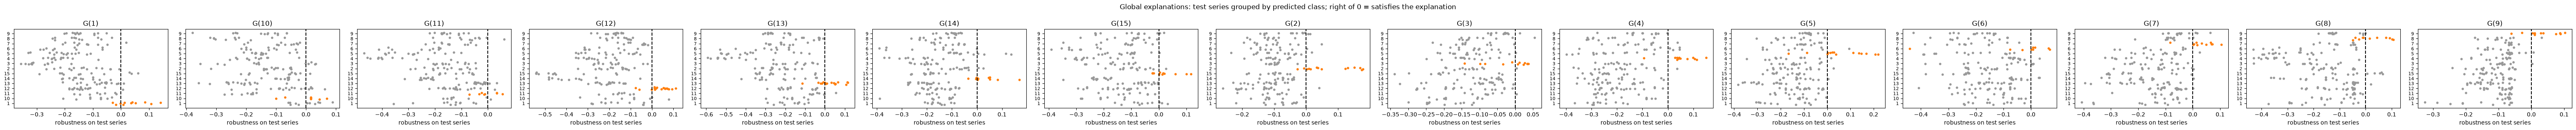

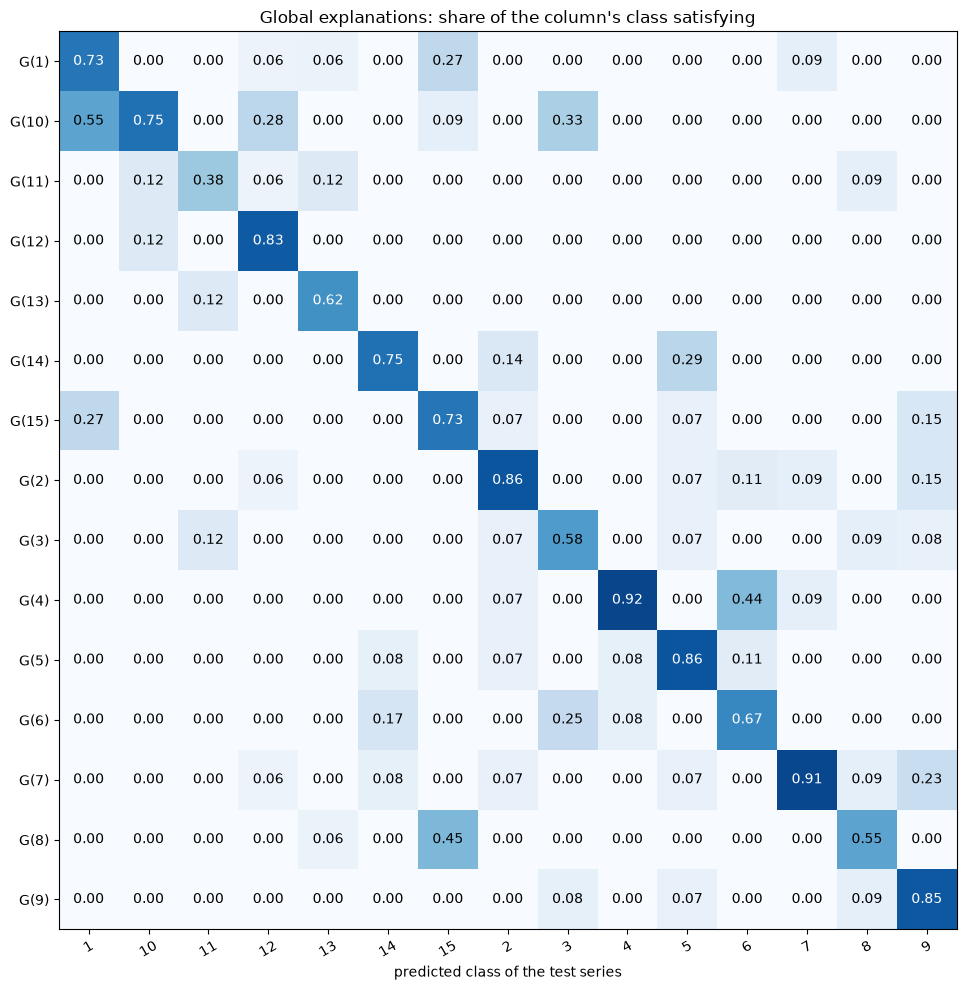

In [18]:
def plot_separation(G, title):
    ks, lab = sorted(G), pred["test"]
    accept = np.zeros((len(ks), len(classes)))
    fig, axs = plt.subplots(1, len(ks), figsize=(4.2 * len(ks), 3.2), squeeze=False)
    for a, k in enumerate(ks):
        rho, ax = eval_robustness(or_of(G[k]), X_te), axs[0][a]
        for c in range(len(classes)):
            r = rho[lab == c]
            ax.scatter(r, c + np.random.default_rng(c).uniform(-.25, .25, len(r)), s=10,
                       c="tab:orange" if c == k else "0.6")
            accept[a, c] = (r > 0).mean() if len(r) else np.nan
        ax.axvline(0, ls="--", c="k")
        ax.set_yticks(range(len(classes)), classes, fontsize=8)
        ax.set(title=f"G({classes[k]})", xlabel="robustness on test series")
    fig.suptitle(f"{title}: test series grouped by predicted class; right of 0 = satisfies the explanation")
    plt.tight_layout(); plt.show()

    fig, ax = plt.subplots(figsize=(1.5 + 1.1 * len(classes), 1 + 0.6 * len(ks)))
    ax.imshow(accept, vmin=0, vmax=1, cmap="Blues")
    for a in range(len(ks)):
        for c in range(len(classes)):
            ax.text(c, a, f"{accept[a, c]:.2f}", ha="center", va="center", color="w" if accept[a, c] > .6 else "k")
    ax.set_xticks(range(len(classes)), classes, rotation=30)
    ax.set_yticks(range(len(ks)), [f"G({classes[k]})" for k in ks])
    ax.set(xlabel="predicted class of the test series", title=f"{title}: share of the column's class satisfying")
    plt.tight_layout(); plt.show()

plot_separation(G, "Global explanations")